# Notebook 3: DDIM Inversion and Latent Interpolation

**Goal**: Showcase the two unique properties of DDIM (η=0) that DDPM lacks:
invertibility (real image → latent → reconstruction) and semantic structure
of the latent space (SLERP, LERP interpolation).

**Paper equations tested**:
- Song et al. 2020, Eq. 12 reversed (η=0): DDIM inversion forward step.
- Song et al. 2020, Fig. 8: latent SLERP interpolation.

DDIM inversion exploits the fact that the deterministic (η=0) sampling
process is invertible: we can run the DDIM forward (noise-adding) direction
using the learned model ε_θ to obtain a latent x_T such that running
DDIM sampling from x_T reconstructs x_0.

The forward DDIM step (Song et al. 2020, implicit Eq. 12 reversed, η=0):

$$x_t = \sqrt{\frac{\alpha_t}{\alpha_{t-1}}} \cdot x_{t-1} + \sqrt{1 - \alpha_t} \cdot \left( 1 - \sqrt{ \frac{\alpha_t}{\alpha_{t-1}} \cdot \frac{1-\alpha_{t-1}}{1-\alpha_t} } \right) \cdot \epsilon_\theta(x_{t-1}, t-1)$$

Equivalently, this is explicit Euler on the probability-flow ODE in the
forward (increasing t) direction. The approximation improves with more steps.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms

from src.schedule import make_beta_schedule, compute_alphas, make_tau
from src.scheduler import DDIMScheduler
from src.sampling import denoise_steps
from src.models import load_model
from src.inversion import ddim_invert, reconstruction_psnr
from src.interpolation import interpolation_path
from src.utils import get_device, save_grid

DEVICE = get_device()
DTYPE  = torch.float16 if DEVICE.type == 'cuda' else torch.float32
Path('../results/figures').mkdir(parents=True, exist_ok=True)
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
T = 1000
betas = make_beta_schedule('linear', T=T, beta_start=1e-4, beta_end=0.02)
_, alpha_bars = compute_alphas(betas)
scheduler = DDIMScheduler(alpha_bars, eta=0.0)

# CIFAR-10 model
eps_fn_cifar, _ = load_model('cifar10', device=DEVICE, dtype=DTYPE)

An error occurred while trying to fetch /home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/weights/ddpm_ema_cifar10: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/weights/ddpm_ema_cifar10.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


## 1. DDIM Inversion on CIFAR-10 (NFE=100)

Take 4 real CIFAR-10 training images, invert them to x_T, then re-sample.
Show: (original | x_T heatmap | reconstruction) triplets.
DDIM inversion inverts the deterministic reverse process (Euler in forward time).

In [3]:
# Load 4 CIFAR-10 train images (rescaled to [-1, 1])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3), 
])
cifar_data = datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
real_images = torch.stack([cifar_data[i][0] for i in range(4)]).to(DEVICE)

print(f'Real images shape: {real_images.shape}, range: [{real_images.min():.2f}, {real_images.max():.2f}]')

Real images shape: torch.Size([4, 3, 32, 32]), range: [-1.00, 1.00]


/home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Reconstruction PSNR at NFE=5: 9.62 dB
Reconstruction PSNR at NFE=10: 11.89 dB
Reconstruction PSNR at NFE=20: 14.01 dB
Reconstruction PSNR at NFE=40: 21.72 dB
Reconstruction PSNR at NFE=80: 28.25 dB
Reconstruction PSNR at NFE=100: 29.65 dB
(>25 dB at NFE=75, >30 dB at NFE=120)


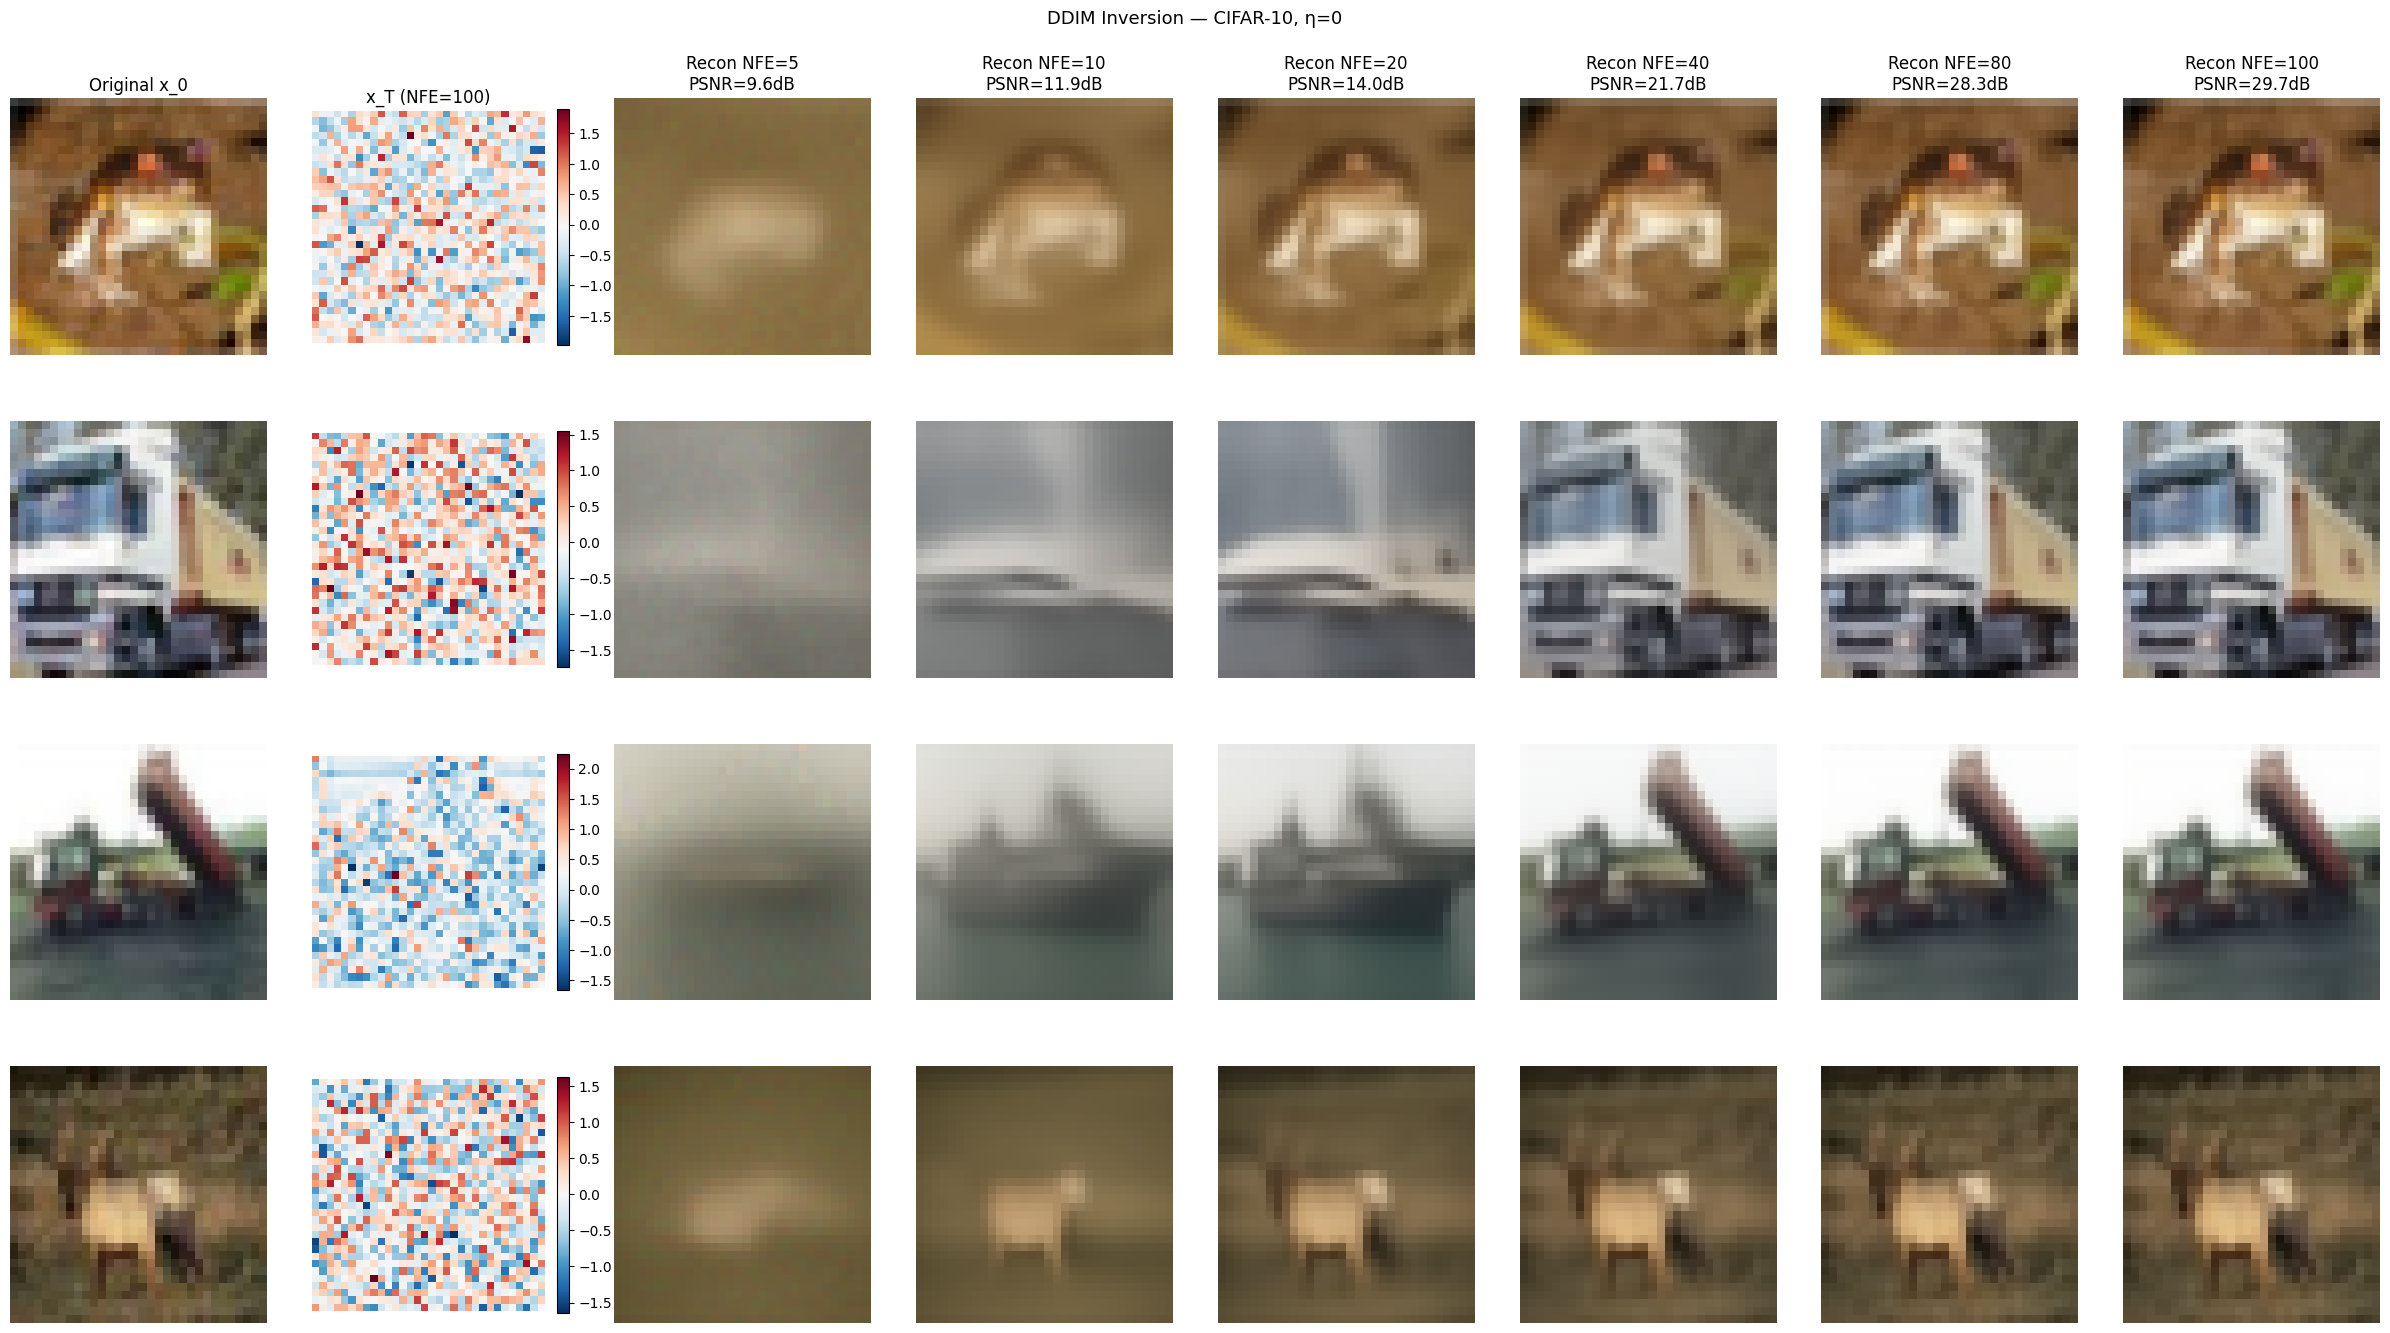

In [9]:
NFE_LIST = [5, 10, 20, 40, 80, 100]
results = {}
for nfe in NFE_LIST:
    x_T_inv = ddim_invert(eps_fn_cifar, real_images.float(), alpha_bars, num_steps=nfe)
    tau = make_tau(T, nfe, 'uniform')
    x_recon = denoise_steps(
        eps_fn=eps_fn_cifar,
        scheduler=scheduler,
        x_start=x_T_inv.to(DEVICE).float(),
        tau=tau,
        eta=0.0,
        clip_sample=False,
        store_intermediates=False,
    )
    psnr = reconstruction_psnr(real_images.cpu().float(), x_recon.cpu())
    results[nfe] = (x_T_inv, x_recon, psnr)
    print(f'Reconstruction PSNR at NFE={nfe}: {psnr:.2f} dB')
print('(>25 dB at NFE=75, >30 dB at NFE=120)')

ncols = 2 + len(NFE_LIST)
fig, axes = plt.subplots(4, ncols, figsize=(3 * ncols, 14))
ref_nfe = NFE_LIST[-1]
for i in range(4):
    orig = (real_images[i].cpu().permute(1, 2, 0).numpy() + 1) / 2
    axes[i, 0].imshow(orig.clip(0, 1))
    if i == 0:
        axes[i, 0].set_title('Original x_0')
    lat = results[ref_nfe][0][i].cpu().mean(0).numpy()
    im = axes[i, 1].imshow(lat, cmap='RdBu_r')
    if i == 0:
        axes[i, 1].set_title(f'x_T (NFE={ref_nfe})')
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046)
    for j, nfe in enumerate(NFE_LIST):
        _, x_recon, psnr = results[nfe]
        recon = (x_recon[i].cpu().permute(1, 2, 0).numpy() + 1) / 2
        axes[i, 2 + j].imshow(recon.clip(0, 1))
        if i == 0:
            axes[i, 2 + j].set_title(f'Recon NFE={nfe}\nPSNR={psnr:.1f}dB')
    for ax in axes[i]:
        ax.axis('off')
plt.suptitle('DDIM Inversion — CIFAR-10, η=0', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/03_inversion_cifar10.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. PSNR vs NFE (50 images)

More inversion steps → finer Euler discretization of the forward ODE → better reconstruction.

NFE=  10  PSNR=12.06 dB
NFE=  20  PSNR=15.21 dB
NFE=  50  PSNR=21.80 dB
NFE= 100  PSNR=25.98 dB
NFE= 200  PSNR=28.61 dB


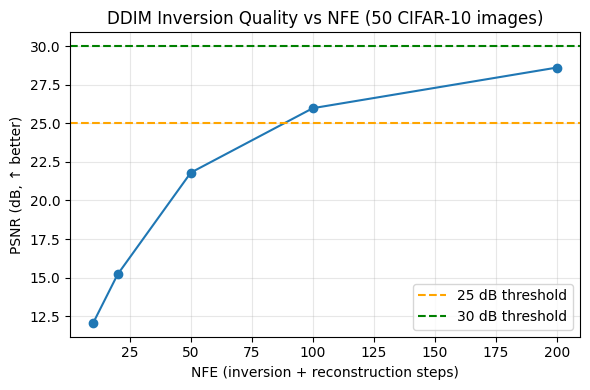

In [6]:
N_PSNR = 50
nfe_list = [10, 20, 50, 100, 200]
psnr_mean = []

real_batch = torch.stack([cifar_data[i][0] for i in range(N_PSNR)]).to(DEVICE).float()

for nfe in nfe_list:
    x_T_batch = ddim_invert(eps_fn_cifar, real_batch, alpha_bars, num_steps=nfe)
    tau_nfe = make_tau(T, nfe, 'uniform')

    x_r = denoise_steps(
        eps_fn=eps_fn_cifar,
        scheduler=scheduler,
        x_start=x_T_batch.to(DEVICE).float(),
        tau=tau_nfe,
        eta=0.0,
        clip_sample=False,
        store_intermediates=False,
    )

    p = reconstruction_psnr(real_batch.cpu(), x_r.cpu())
    psnr_mean.append(p)
    print(f'NFE={nfe:4d}  PSNR={p:.2f} dB')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(nfe_list, psnr_mean, marker='o')
ax.axhline(25, color='orange', linestyle='--', label='25 dB threshold')
ax.axhline(30, color='green', linestyle='--', label='30 dB threshold')
ax.set_xlabel('NFE (inversion + reconstruction steps)')
ax.set_ylabel('PSNR (dB, ↑ better)')
ax.set_title('DDIM Inversion Quality vs NFE (50 CIFAR-10 images)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/03_psnr_vs_nfe.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SLERP Interpolation on LSUN Bedroom 256×256

Sample two latents z_1, z_2 ~ N(0,I) and interpolate via SLERP.
Reproduces Fig. 8 of Song et al. 2020. The semantic content transitions
smoothly because DDIM (η=0) is a continuous, invertible mapping.

SLERP formula (Shoemake 1985):
  `slerp(z_1, z_2, α) = sin((1−α)θ)/sin(θ) · z_1 + sin(αθ)/sin(θ) · z_2`

/home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch google/ddpm-ema-bedroom-256: google/ddpm-ema-bedroom-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


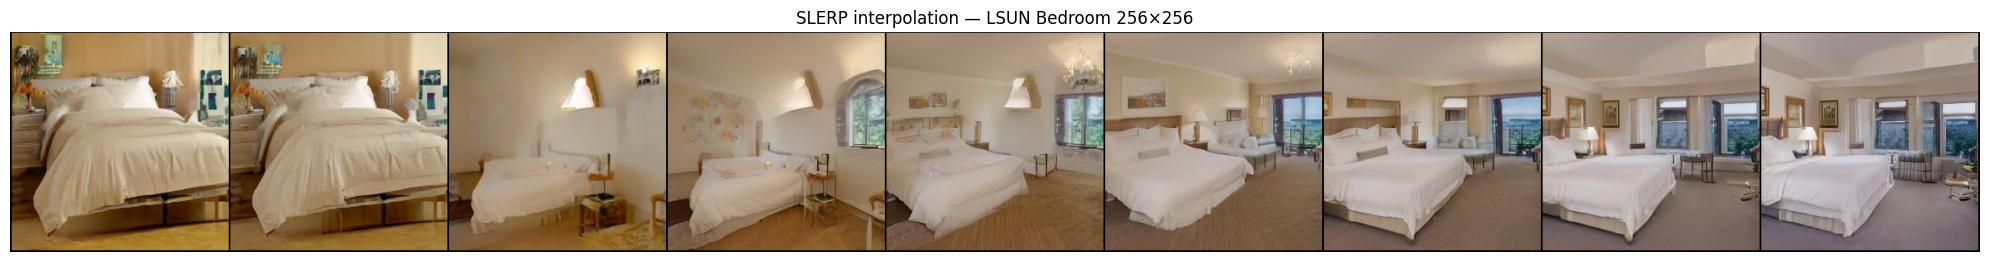

In [7]:
eps_fn_bedroom, _ = load_model('google/ddpm-ema-bedroom-256', device=DEVICE, dtype=DTYPE)
scheduler_bedroom = DDIMScheduler(alpha_bars, eta=0.0)

N_INTERP = 9   # number of interpolation steps (includes endpoints)
NFE_INTERP = 50

torch.manual_seed(42)
torch.manual_seed(99)
z1_bed = torch.randn(1, 3, 256, 256, device=DEVICE)
z2_bed = torch.randn(1, 3, 256, 256, device=DEVICE)
z_path_bed = interpolation_path(z1_bed, z2_bed, num_steps=N_INTERP, method='slerp')

tau = make_tau(T, NFE_INTERP, 'uniform')
images_bed = []
gen = torch.Generator(device=DEVICE).manual_seed(42)
for z_alpha in z_path_bed:
    x = denoise_steps(
        eps_fn=eps_fn_bedroom,
        scheduler=scheduler_bedroom,
        x_start=z_alpha.to(DEVICE).to(DTYPE),
        tau=tau,
        eta=0.0,
        clip_sample=False,
        store_intermediates=False,
        generator=gen,
    )
    images_bed.append(x.cpu().float())

grid_bed = torch.cat(images_bed, dim=0)
save_grid(grid_bed, '../results/figures/03_slerp_bedroom.png', nrow=N_INTERP)

fig, ax = plt.subplots(figsize=(20, 3))
ax.imshow(plt.imread('../results/figures/03_slerp_bedroom.png'))
ax.axis('off')
ax.set_title('SLERP interpolation — LSUN Bedroom 256×256')
plt.tight_layout()
plt.show()

## 4. SLERP vs LERP comparison

LERP intermediate latents have collapsed norm at the midpoint: ||(1−α)z_1 + αz_2||₂ ≈ cos(θ/2) · ||z||₂ at α=0.5.
This shifts the midpoint sample away from the prior (Gaussian), producing lower quality / different style images.
What happens if we normalize the interpolation such that LERP maintains the variance?

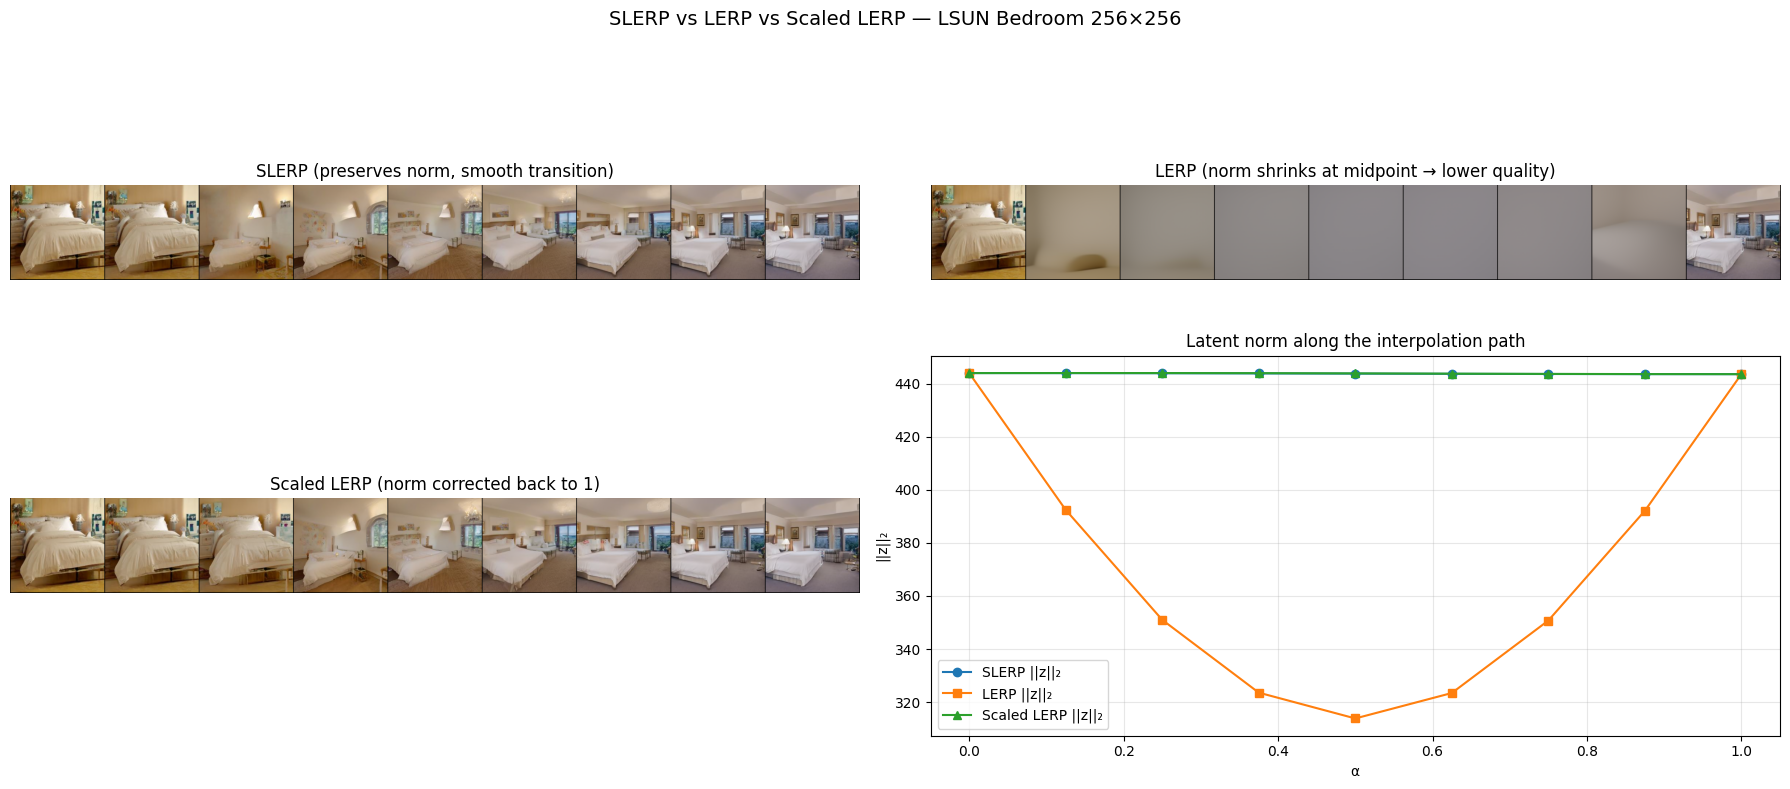

Notebook 3 complete.


In [8]:
z_path_lerp = interpolation_path(z1_bed, z2_bed, num_steps=N_INTERP, method='lerp')
alphas_path = [i / (N_INTERP - 1) for i in range(N_INTERP)]

z_path_scaled = [z / math.sqrt((1 - a)**2 + a**2) for a, z in zip(alphas_path, z_path_lerp)]

images_lerp = []
images_scaled = []

for z_alpha_lerp, z_alpha_scaled in zip(z_path_lerp, z_path_scaled):
    tau = make_tau(T, NFE_INTERP, 'uniform')
    x_lerp = z_alpha_lerp.to(DEVICE).to(DTYPE)
    x_scaled = z_alpha_scaled.to(DEVICE).to(DTYPE)
    
    with torch.no_grad():
        for i in reversed(range(len(tau))):
            t = int(tau[i])
            t_prev = int(tau[i-1]) if i > 0 else -1
            
            eps_lerp = eps_fn_bedroom(x_lerp, t)
            x_lerp = scheduler_bedroom.step(eps_lerp, x_lerp, t, t_prev)
            
            eps_scaled = eps_fn_bedroom(x_scaled, t)
            x_scaled = scheduler_bedroom.step(eps_scaled, x_scaled, t, t_prev)
            
    images_lerp.append(x_lerp.cpu().float())
    images_scaled.append(x_scaled.cpu().float())

grid_lerp = torch.cat(images_lerp, dim=0)
save_grid(grid_lerp, '../results/figures/03_lerp_bedroom.png', nrow=N_INTERP)

grid_scaled = torch.cat(images_scaled, dim=0)
save_grid(grid_scaled, '../results/figures/03_scaled_lerp_bedroom.png', nrow=N_INTERP)

slerp_norms = [z.norm().item() for z in z_path_bed]
lerp_norms  = [z.norm().item() for z in z_path_lerp]
scaled_norms = [z.norm().item() for z in z_path_scaled]

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

axes[0, 0].imshow(plt.imread('../results/figures/03_slerp_bedroom.png'))
axes[0, 0].set_title('SLERP (preserves norm, smooth transition)')
axes[0, 0].axis('off')

axes[0, 1].imshow(plt.imread('../results/figures/03_lerp_bedroom.png'))
axes[0, 1].set_title('LERP (norm shrinks at midpoint → lower quality)')
axes[0, 1].axis('off')

axes[1, 0].imshow(plt.imread('../results/figures/03_scaled_lerp_bedroom.png'))
axes[1, 0].set_title('Scaled LERP (norm corrected back to 1)')
axes[1, 0].axis('off')

axes[1, 1].plot(alphas_path, slerp_norms, marker='o', label='SLERP ||z||₂')
axes[1, 1].plot(alphas_path, lerp_norms,  marker='s', label='LERP ||z||₂')
axes[1, 1].plot(alphas_path, scaled_norms, marker='^', label='Scaled LERP ||z||₂')
axes[1, 1].set_xlabel('α')
axes[1, 1].set_ylabel('||z||₂')
axes[1, 1].set_title('Latent norm along the interpolation path')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('SLERP vs LERP vs Scaled LERP — LSUN Bedroom 256×256', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/03_slerp_vs_lerp_vs_scaled.png', dpi=100, bbox_inches='tight')
plt.show()
print('Notebook 3 complete.')